# Neuro-Symbolic Reasoning: FOLIO+ProofWriter+RuleTaker+CLUTRR

This notebook demonstrates the **dataset assembly pipeline** for the neuro-symbolic reasoning benchmark.

**What this artifact does:**  
Loads four HuggingFace reasoning datasets (FOLIO, ProofWriter, RuleTaker, CLUTRR) and converts them to a unified `exp_sel_data_out` schema for hypothesis testing around hallucination in neuro-symbolic multi-hop reasoning.

Each example is standardized to: `{input, output, metadata_id, metadata_depth, metadata_split, metadata_gold_predicate_count, ...}`

This demo runs on a curated 24-example FOLIO subset to show the pipeline quickly. The full run produces 16,204 examples across all four datasets.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import sys
from pathlib import Path
from collections import defaultdict
import random
import matplotlib
import matplotlib.pyplot as plt
from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data Loading

Load the mini demo dataset. The helper tries GitHub first (for Colab), then falls back to a local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-fec6cc-proof-residual-directed-knowledge-elicit/main/iter_1/gen_art_dataset_1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data: {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    rows_key = 'rows' if 'rows' in ds else 'examples'
    print(f"  {ds['dataset']}: {len(ds[rows_key])} rows")

Loaded data: 1 dataset(s)
  folio: 24 rows


## Config

Tunable parameters. Set to minimum values for the demo; increase for a full run.

In [5]:
# Max examples per dataset to include in full production run
# Demo: set to 10 for fast execution
# Full run (original value): 5000
MAX_PER_DATASET = 10

# Random seed for reproducible stratified sampling
RANDOM_SEED = 42

## Input Formatting

`format_input` converts each example's premises + hypothesis into a single string.
CLUTRR gets a "Story/Query" format; other datasets get "Context/Question" format.

In [6]:
def format_input(row: dict) -> str:
    """Format premises + hypothesis into a structured text input."""
    premises = row.get("premises", [])
    hypothesis = row.get("hypothesis", "")
    dataset = row.get("dataset", "")

    if dataset == "clutrr":
        # CLUTRR: story + kinship query
        story_text = " ".join(p.rstrip(".").strip() for p in premises if p.strip())
        return f"Story: {story_text}. Query: {hypothesis}"
    else:
        # FOLIO, ProofWriter, RuleTaker: premises as facts/rules + hypothesis as question
        if premises:
            premises_text = " ".join(p.strip() for p in premises if p.strip())
            return f"Context: {premises_text} Question: {hypothesis}"
        else:
            return f"Question: {hypothesis}"

## Row Conversion

`row_to_example` maps a unified-schema row into the `exp_sel_data_out` format.
Dataset-specific metadata fields are appended depending on the source dataset.

In [7]:
def row_to_example(row: dict) -> dict:
    """Convert a unified-schema row to exp_sel_data_out example format."""
    input_text = format_input(row)
    output_text = str(row.get("label", ""))

    example = {
        "input": input_text,
        "output": output_text,
        "metadata_id": str(row.get("id", "")),
        "metadata_depth": int(row.get("depth", 0)),
        "metadata_split": str(row.get("split", "")),
        "metadata_gold_predicate_count": int(len(row.get("gold_predicates", []))),
        "metadata_task_type": "classification",
    }

    # Dataset-specific metadata
    dataset = row.get("dataset", "")
    meta = row.get("metadata", {}) or {}

    if dataset == "folio":
        example["metadata_n_classes"] = 3
        example["metadata_label_space"] = "True|False|Uncertain"
        if meta.get("story_id") is not None:
            example["metadata_story_id"] = str(meta["story_id"])
    elif dataset == "proofwriter":
        example["metadata_n_classes"] = 3
        example["metadata_label_space"] = "True|False|Unknown"
        example["metadata_config"] = str(meta.get("config", ""))
    elif dataset == "ruletaker":
        example["metadata_n_classes"] = 2
        example["metadata_label_space"] = "entailment|not entailment"
        example["metadata_config"] = str(meta.get("config", ""))
    elif dataset == "clutrr":
        example["metadata_n_classes"] = 20  # kinship relations
        example["metadata_label_space"] = "kinship_relation"
        example["metadata_f_comb"] = str(meta.get("f_comb", ""))
        example["metadata_task_name"] = str(meta.get("task_name", ""))

    return example

## Dataset Loading and Conversion

`load_and_convert` processes a list of examples: caps rows via stratified label-balanced sampling, then calls `row_to_example` on each.

In the demo we work directly from the loaded `data` variable instead of reading raw HuggingFace full files from disk.

In [8]:
def load_and_convert(rows: list, dataset_name: str, max_rows: int = MAX_PER_DATASET) -> dict:
    """Load a list of rows and convert to dataset entry.
    
    In the original script this function read a full_*.json file from disk.
    Here rows come from the pre-loaded demo data variable.
    """
    logger.info(f"Loading {dataset_name}, {len(rows)} input rows...")

    # Cap rows
    if len(rows) > max_rows:
        # Stratified sample by label
        random.seed(RANDOM_SEED)
        groups: dict = defaultdict(list)
        for r in rows:
            groups[r.get("label", "unknown")].append(r)
        sampled = []
        per_class = max_rows // len(groups)
        for cls_rows in groups.values():
            sampled.extend(random.sample(cls_rows, min(per_class, len(cls_rows))))
        # Fill remainder
        remainder = [r for r in rows if r not in sampled]
        random.shuffle(remainder)
        while len(sampled) < max_rows and remainder:
            sampled.append(remainder.pop())
        rows = sampled[:max_rows]
        logger.info(f"  Sampled {len(rows)} rows from {len(groups)} label classes")
    else:
        logger.info(f"  Using all {len(rows)} rows")

    examples = []
    for row in rows:
        try:
            ex = row_to_example(row)
            examples.append(ex)
        except Exception as e:
            logger.debug(f"  Skipped row {row.get('id', '?')}: {e}")

    logger.info(f"  {dataset_name}: {len(examples)} examples")
    return {"dataset": dataset_name, "examples": examples}

## Main Pipeline

Process each dataset from the loaded demo data, then assemble the output structure.

The original script read raw HuggingFace JSON files for all four datasets.
Here we use the pre-converted `data` variable (already in exp_sel_data_out format) as the source rows for the demo.

In [9]:
logger.info("=== Building full_data_out ===")

datasets = []
for ds_entry in data["datasets"]:
    dataset_name = ds_entry["dataset"]
    # Demo data uses 'rows' key (raw unified-schema rows); full run uses disk files
    rows = ds_entry.get("rows", ds_entry.get("examples", []))

    entry = load_and_convert(rows, dataset_name)
    if entry["examples"]:
        datasets.append(entry)

output = {
    "metadata": {
        "description": "Neuro-symbolic reasoning benchmarks: FOLIO, ProofWriter, RuleTaker, CLUTRR",
        "source": "HuggingFace: tasksource/folio, tasksource/proofwriter, tasksource/ruletaker, kendrivp/CLUTRR_v1_extracted",
        "schema_version": "exp_sel_data_out_v1",
    },
    "datasets": datasets,
}

total = sum(len(d["examples"]) for d in datasets)
logger.info(f"Built output: {len(datasets)} datasets, {total} total examples")

01:50:38|INFO   |=== Building full_data_out ===


01:50:38|INFO   |Loading folio, 24 input rows...


01:50:38|INFO   |  Sampled 10 rows from 3 label classes


01:50:38|INFO   |  folio: 10 examples


01:50:38|INFO   |Built output: 1 datasets, 10 total examples


## Results & Visualization

Summary statistics and plots for the assembled dataset.

Dataset           Examples                         Labels  Avg depth  Avg gold preds
--------------------------------------------------------------------------------
folio                   10   False:3, True:3, Uncertain:4       3.00           14.50

Total examples: 10


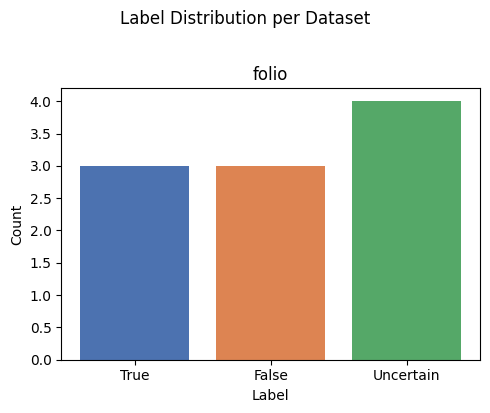


--- Example output record ---
  input: Context: All people who regularly drink coffee are dependent on caffeine. People regularly drink cof
  output: True
  metadata_id: folio_1127
  metadata_depth: 3
  metadata_split: train
  metadata_gold_predicate_count: 12
  metadata_task_type: classification
  metadata_n_classes: 3
  metadata_label_space: True|False|Uncertain
  metadata_story_id: 406


In [10]:
from collections import Counter

# Per-dataset summary table
print(f"{'Dataset':<15} {'Examples':>10} {'Labels':>30} {'Avg depth':>10} {'Avg gold preds':>15}")
print("-" * 80)
for ds in datasets:
    exs = ds["examples"]
    label_counts = Counter(e["output"] for e in exs)
    labels_str = ", ".join(f"{k}:{v}" for k, v in sorted(label_counts.items()))
    avg_depth = sum(e["metadata_depth"] for e in exs) / len(exs)
    avg_preds = sum(e["metadata_gold_predicate_count"] for e in exs) / len(exs)
    print(f"{ds['dataset']:<15} {len(exs):>10} {labels_str:>30} {avg_depth:>10.2f} {avg_preds:>15.2f}")

print(f"\nTotal examples: {total}")

# Visualize label distribution per dataset
fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4))
if len(datasets) == 1:
    axes = [axes]
for ax, ds in zip(axes, datasets):
    exs = ds["examples"]
    label_counts = Counter(e["output"] for e in exs)
    ax.bar(label_counts.keys(), label_counts.values(), color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title(ds["dataset"])
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
plt.suptitle("Label Distribution per Dataset", y=1.02)
plt.tight_layout()
plt.show()

# Show one example
print("\n--- Example output record ---")
ex = datasets[0]["examples"][0]
for k, v in ex.items():
    val_str = str(v)[:100]
    print(f"  {k}: {val_str}")